In [1]:
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver
from langchain_openai import ChatOpenAI

In [ ]:
import os

os.environ["OPENAI_API_KEY"] = ""

In [3]:
class LoanState(TypedDict):
    prompt: str
    pan: str
    monthly_income: float
    emi_outstanding: float
    credit_score: int
    foir: float
    decision: str
    reason: str

In [ ]:
class ParsedApplication(TypedDict):
    pan: str
    monthly_income: float
    existing_emi: float

In [19]:
# Node 1
parser_model = ChatOpenAI(model="gpt-3.5-turbo", temperature=0)
structured_parser = parser_model.with_structured_output(ParsedApplication)

def parse_application(state: LoanState) -> dict:
    """LLM node: turns the free-text prompt into the typed fields the rest of the graph needs."""
    parsed: ParsedApplication = structured_parser.invoke(
        "Extract the PAN number, monthly income, and existing EMI from this loan "
        f"application request:\n\n{state['prompt']}"
    )
    print(f"[parse_application] parsed = {parsed}")
    return {
        "pan": parsed["pan"],
        "monthly_income": parsed["monthly_income"],
        "emi_outstanding": parsed["existing_emi"],
    }

In [20]:
# Node 2 - Fetch Credit score

def fetch_credit_score(state: LoanState) -> dict:
    """Stand-in for a real CIBIL API call, keyed by PAN."""
    fake_bureau = {"ABCDE1234F": 762, "XYZAB9876K": 640}
    score = fake_bureau.get(state["pan"], 700)
    print(f"[fetch_credit_score] score = {score}")
    return {"credit_score": score}          # merged into state

In [22]:
# Node 3 - Calculate foir

def compute_foir(state: LoanState) -> dict:
    foir = round((state["emi_outstanding"] / state["monthly_income"]) * 100, 1)
    print(f"[compute_foir] FOIR = {foir}%")
    return {"foir": foir}

In [23]:
# Node 4 - Decision

def decide(state: LoanState) -> dict:
    """Bank policy lives here — deterministic, not LLM-decided."""
    if state["credit_score"] < 700:
        return {"decision": "REJECT",
                "reason": f"Credit score {state['credit_score']} below cut-off 700"}
    if state["foir"] > 50:
        return {"decision": "REJECT",
                "reason": f"FOIR {state['foir']}% exceeds policy cap 50%"}
    return {"decision": "APPROVE",
            "reason": f"Score {state['credit_score']}, FOIR {state['foir']}% within policy"}

In [24]:
# Router
def route(state: LoanState) -> Literal["approve_note", "reject_note"]:
    return "approve_note" if state["decision"] == "APPROVE" else "reject_note"

In [25]:
# Node 5 - Approve

def approve_note(state: LoanState) -> dict:
    print(f"[approve_note] {state['pan']} APPROVED — {state['reason']}")
    return {}


In [26]:
# Node 6 - Reject

def reject_note(state: LoanState) -> dict:
    print(f"[reject_note] {state['pan']} REJECTED — {state['reason']}")
    return {}

In [27]:
# Building the graph

builder = StateGraph(LoanState)

# Adding the nodes

builder.add_node("parse_application", parse_application)
builder.add_node("fetch_credit_score", fetch_credit_score)
builder.add_node("compute_foir", compute_foir)
builder.add_node("decide", decide)
builder.add_node("approve_note", approve_note)
builder.add_node("reject_note", reject_note)


# Establishing the connection - Edge
builder.add_edge(START, "parse_application")
builder.add_edge("parse_application", "fetch_credit_score")
builder.add_edge("fetch_credit_score", "compute_foir")
builder.add_edge("compute_foir", "decide")

builder.add_conditional_edges(
    "decide", route,
    {"approve_note" : "approve_note", "reject_note": "reject_note"}
)

builder.add_edge("approve_note", END)
builder.add_edge("reject_note", END)

graph = builder.compile(checkpointer=InMemorySaver())

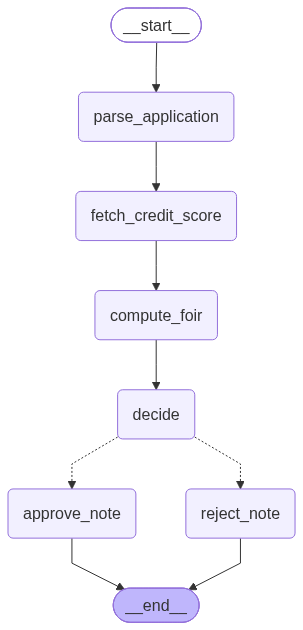

In [28]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
applicant_prompts = {
    "Ravi Kumar": "PAN ABCDE1234F, monthly income 90000, existing EMI 30000. Notification Channel : SMS. Eligible?",   # good score, good FOIR  -> APPROVE
    "Anitha S":   "PAN XYZAB9876K, monthly income 60000, existing EMI 20000. Eligible?",   # low score              -> REJECT
    "Meena R":    "PAN LMNOP5678K, monthly income 50000, existing EMI 30000. Eligible?",   # ok score, FOIR too high-> REJECT
}

In [30]:
for name, prompt in applicant_prompts.items():
    print("-" * 55)
    out = graph.invoke(
        {"prompt": prompt},
        config= { "configurable" : {"thread_id" : name} }
    )
    print(f"Final: {out['decision']} | {out['reason']}")

-------------------------------------------------------
[parse_application] parsed = {'pan': 'ABCDE1234F', 'monthly_income': 90000, 'existing_emi': 30000}
[fetch_credit_score] score = 762
[compute_foir] FOIR = 33.3%
[approve_note] ABCDE1234F APPROVED — Score 762, FOIR 33.3% within policy
Final: APPROVE | Score 762, FOIR 33.3% within policy
-------------------------------------------------------
[parse_application] parsed = {'pan': 'XYZAB9876K', 'monthly_income': 60000, 'existing_emi': 20000}
[fetch_credit_score] score = 640
[compute_foir] FOIR = 33.3%
[reject_note] XYZAB9876K REJECTED — Credit score 640 below cut-off 700
Final: REJECT | Credit score 640 below cut-off 700
-------------------------------------------------------
[parse_application] parsed = {'pan': 'LMNOP5678K', 'monthly_income': 50000, 'existing_emi': 30000}
[fetch_credit_score] score = 700
[compute_foir] FOIR = 60.0%
[reject_note] LMNOP5678K REJECTED — FOIR 60.0% exceeds policy cap 50%
Final: REJECT | FOIR 60.0% exceeds